# Job Market Analytics Using Python and SQL

## Objective

The objective of this project is to analyze data science job market trends, salaries, experience levels, company sizes, and remote work opportunities using Python and SQL.

## Data Loading

In this section, the required Python library is imported and the dataset is loaded into a Pandas DataFrame. The first few records are displayed to verify that the dataset has been loaded successfully and to understand its structure.

In [3]:

import pandas as pd
df=pd.read_csv(r'C:/Users/Vaishanvi J/OneDrive/Desktop/Job-Market-Analytics/ds_salaries.csv ')
print(df.head())

   Unnamed: 0  work_year experience_level employment_type  \
0           0       2020               MI              FT   
1           1       2020               SE              FT   
2           2       2020               SE              FT   
3           3       2020               MI              FT   
4           4       2020               SE              FT   

                    job_title  salary salary_currency  salary_in_usd  \
0              Data Scientist   70000             EUR          79833   
1  Machine Learning Scientist  260000             USD         260000   
2           Big Data Engineer   85000             GBP         109024   
3        Product Data Analyst   20000             USD          20000   
4   Machine Learning Engineer  150000             USD         150000   

  employee_residence  remote_ratio company_location company_size  
0                 DE             0               DE            L  
1                 JP             0               JP            S  

## Data Cleaning
In this step, unnecessary columns are removed from the dataset to improve data quality and simplify the analysis. The `Unnamed: 0` column is dropped because it represents an index column that does not provide meaningful information for the analysis.

In [55]:

df.drop(['Unnamed: 0'], axis=1, inplace=True)



In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           607 non-null    int64
 1   experience_level    607 non-null    str  
 2   employment_type     607 non-null    str  
 3   job_title           607 non-null    str  
 4   salary              607 non-null    int64
 5   salary_currency     607 non-null    str  
 6   salary_in_usd       607 non-null    int64
 7   employee_residence  607 non-null    str  
 8   remote_ratio        607 non-null    int64
 9   company_location    607 non-null    str  
 10  company_size        607 non-null    str  
dtypes: int64(4), str(7)
memory usage: 52.3 KB



## Which Jobs Are Most in Demand?
This analysis identifies the most frequently occurring job roles in the dataset. By counting the number of postings for each job title, we can understand which positions are currently in highest demand within the data science industry.
### Insight
Data Scientist and Data Engineer roles appear most frequently in the dataset, indicating strong market demand for professionals with skills in data analysis, machine learning, and data infrastructure.

In [57]:
top_jobs=df['job_title'].value_counts().head(20)
print(top_jobs)

job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
Director of Data Science        7
AI Scientist                    7
Principal Data Scientist        7
Data Analytics Manager          7
Lead Data Engineer              6
BI Data Analyst                 6
ML Engineer                     6
Computer Vision Engineer        6
Business Data Analyst           5
Data Engineering Manager        5
Name: count, dtype: int64



## Which Job Roles Offer the Highest Salaries?
This analysis calculates the average salary (in USD) for each job title and ranks them in descending order. The objective is to identify the highest-paying roles in the data science job market.
### Insight
The results show that **Data Analytics Lead** has the highest average salary among the analyzed job roles. This suggests that leadership positions, which combine technical expertise with strategic decision-making responsibilities, tend to receive higher compensation.

In [58]:
print(
     df.groupby('job_title')['salary_in_usd']
       .mean()
       .sort_values(ascending=False)
        .head(20)

)

job_title
Data Analytics Lead                   405000.000000
Principal Data Engineer               328333.333333
Financial Data Analyst                275000.000000
Principal Data Scientist              215242.428571
Director of Data Science              195074.000000
Data Architect                        177873.909091
Applied Data Scientist                175655.000000
Analytics Engineer                    175000.000000
Data Specialist                       165000.000000
Head of Data                          160162.600000
Machine Learning Scientist            158412.500000
Data Science Manager                  158328.500000
Director of Data Engineering          156738.000000
Head of Data Science                  146718.750000
Applied Machine Learning Scientist    142068.750000
Lead Data Engineer                    139724.500000
Data Analytics Manager                127134.285714
Cloud Data Engineer                   124647.000000
Data Engineering Manager              123227.200000
Pr

In [59]:
print(
    df.groupby('job_title')['salary']
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .tail(10)
)

job_title
Business Data Analyst        355000.000000
Principal Data Engineer      328333.333333
AI Scientist                 290571.428571
Financial Data Analyst       275000.000000
Machine Learning Engineer    272717.878049
NLP Engineer                 240000.000000
Product Data Analyst         235000.000000
Principal Data Scientist     206714.285714
Director of Data Science     193285.714286
Data Engineer                179210.553030
Name: salary, dtype: float64



## How Common Is Remote Work?
This analysis examines the distribution of remote work arrangements in the data science job market using the `remote_ratio` column.
### Remote Work Categories
* **0** = On-site work
* **50** = Hybrid work
* **100** = Fully remote work
### Insight
The results show that **fully remote work (100%) is the most common work arrangement**, with 381 job postings. In comparison, there are 127 on-site positions and 99 hybrid positions. This indicates that remote work is highly prevalent in the data science industry, offering professionals greater flexibility in their work environment.

In [60]:
 df['remote_ratio'].value_counts()

remote_ratio
100    381
0      127
50      99
Name: count, dtype: int64


## How Has Job Demand Changed Across Experience Levels Over Time?
This analysis explores the number of job postings across different experience levels from 2020 to 2022. By examining hiring trends over time, we can identify which experience levels experienced the greatest growth in demand.
### Experience Levels
* **EN** = Entry Level
* **MI** = Mid Level
* **SE** = Senior Level
* **EX** = Executive Level
### Insight
The number of job postings increased significantly between 2020 and 2022, particularly for **Senior-Level (SE)** professionals. Senior-level roles grew from 18 postings in 2020 to 193 postings in 2022, making them the fastest-growing category. Mid-level (MI) positions also showed strong demand throughout the period, while Executive (EX) roles increased gradually. This suggests that organizations increasingly sought experienced data professionals as the industry expanded.

In [61]:
exp_year=df.groupby(['work_year','experience_level']).size().reset_index(name='job_count')
print(exp_year)

    work_year experience_level  job_count
0        2020               EN         20
1        2020               EX          2
2        2020               MI         32
3        2020               SE         18
4        2021               EN         47
5        2021               EX         11
6        2021               MI         90
7        2021               SE         69
8        2022               EN         21
9        2022               EX         13
10       2022               MI         91
11       2022               SE        193



## Which Countries Offer the Highest Salaries?
This analysis calculates the average salary (in USD) for each company location and ranks countries based on their mean compensation levels. The objective is to identify the countries that offer the highest-paying opportunities in the data science job market.
### Insight
The results show that **Russia (RU)** offers the highest average salary in the dataset, followed by the **United States (US)** and **New Zealand (NZ)**. The United States also maintains consistently high salary levels and represents one of the largest job markets for data professionals. These findings suggest that compensation can vary significantly across countries due to differences in economic conditions, industry demand, and cost of living.

In [62]:
print(
    df.groupby('company_location')['salary_in_usd']
       .mean()
    .sort_values(ascending=False)
    .head(10)
)

company_location
RU    157500.000000
US    144055.261972
NZ    125000.000000
IL    119059.000000
JP    114127.333333
AU    108042.666667
DZ    100000.000000
AE    100000.000000
IQ    100000.000000
CA     99823.733333
Name: salary_in_usd, dtype: float64



### Visualization: Top 10 Countries by Average Salary
The following bar chart compares the average salaries offered across the top-paying countries in the dataset. This visualization makes it easier to identify geographic differences in compensation and highlights the countries with the most competitive salaries.

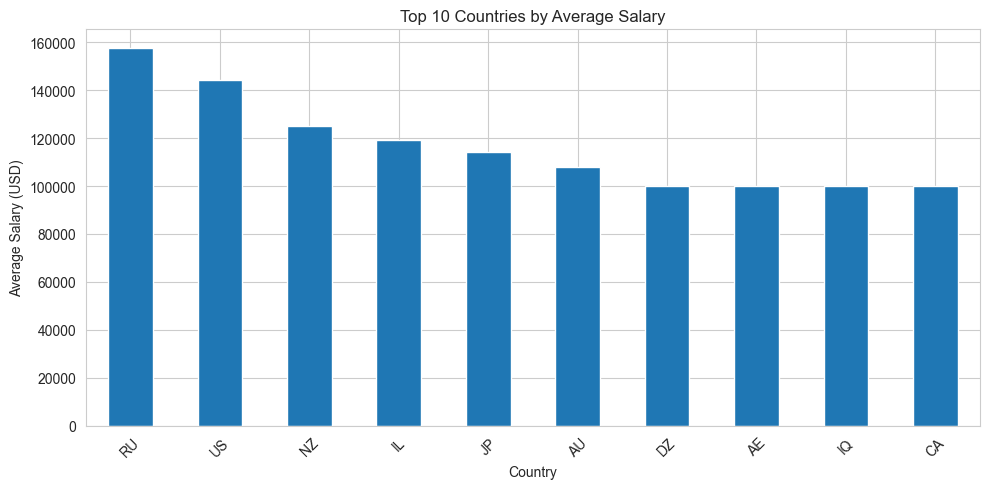

In [63]:
import matplotlib.pyplot as plt
top_countries = (
    df.groupby('company_location')['salary_in_usd']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 5))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Average Salary')
plt.xlabel('Country')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Which Company Size Appears Most Often?

This analysis examines the distribution of company sizes in the dataset. Understanding the prevalence of small, medium, and large organizations helps identify where most data science job opportunities are concentrated.
### Company Size Categories
* **S** = Small Company
* **M** = Medium Company
* **L** = Large Company
### Insight
The results show that **Medium-sized companies (M)** appear most frequently in the dataset, with 326 records. Large companies (L) account for 198 records, while small companies (S) account for 83 records. This suggests that medium-sized organizations are major employers of data science professionals and contribute significantly to job opportunities in the industry.

In [64]:
print(df['company_size'].value_counts())


company_size
M    326
L    198
S     83
Name: count, dtype: int64


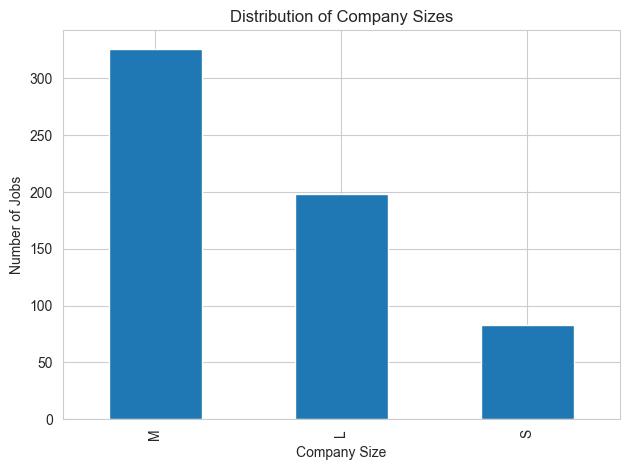

In [65]:
import matplotlib.pyplot as plt

df['company_size'].value_counts().plot(kind='bar')

plt.title('Distribution of Company Sizes')
plt.xlabel('Company Size')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()

## Key Insights
1. Data Scientist and Data Engineer are the most in-demand roles.
2. Data Analytics Lead has the highest average salary in the dataset.
3. Fully remote jobs are more common than hybrid and on-site positions.
4. Senior-level roles experienced the largest growth between 2020 and 2022.
5. Russia offers the highest average salary among the analyzed countries.
6. Medium-sized companies account for the largest share of job postings.

## Conclusion
This project analyzed data science job market trends using Python and SQL. The findings highlight strong demand for data professionals, the growing popularity of remote work, increasing opportunities for experienced candidates, and notable salary differences across job roles and countries. These insights provide valuable information for job seekers, recruiters, and organizations operating in the data science industry.